In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
import os
from tqdm import trange
import matplotlib.pyplot as plt

### Load Data

In [2]:
BASE_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC"
adata = sc.read_h5ad(os.path.join(BASE_PATH, "adata_hvg_with_CNN_embeddings.h5ad"))

In [3]:
print(adata)
print("Gene matrix shape:", adata.X.shape)
print("Metadata columns:", adata.obs.columns)
print("CNN embedding shape:", adata.obsm["X_cnn"].shape)

AnnData object with n_obs × n_vars = 63072 × 150
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_cnn', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Gene matrix shape: (63072, 150)
Metadata columns: Index(['fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y',
       'max_y', 'n_genes_by_count

### Extract Required Data

In [4]:
# Gene features
X_gene = adata.X

if not isinstance(X_gene, np.ndarray):
    X_gene = X_gene.toarray()

# CNN morphology embeddings
X_cnn = adata.obsm["X_cnn"]

print("Gene features:", X_gene.shape)
print("CNN features:", X_cnn.shape)

Gene features: (63072, 150)
CNN features: (63072, 512)


### Scale CNN embeddings

In [5]:
scaler = StandardScaler()
X_cnn_scaled = scaler.fit_transform(X_cnn)

Combine node features

In [6]:
X = np.concatenate([X_gene, X_cnn_scaled], axis=1)

print("Final node feature matrix:", X.shape)

Final node feature matrix: (63072, 662)


### Extract spatial coordinates

In [7]:
coords = adata.obs[["center_x","center_y"]].values

print("Spatial coordinates shape:", coords.shape)


Spatial coordinates shape: (63072, 2)


### Build spatial graph

In [8]:
k = 10

nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

edges = []

for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edges.append([i,j])

edge_index = torch.tensor(edges).t().contiguous()

print("Edge index shape:", edge_index.shape)


Edge index shape: torch.Size([2, 567648])


### Convert to Pytorch Graph

In [9]:
x = torch.tensor(X, dtype=torch.float)

data = Data(x=x, edge_index=edge_index)

print(data)


Data(x=[63072, 662], edge_index=[2, 567648])


### Graph Transformer Model

In [10]:
class GraphTransformer(nn.Module):

    def __init__(self, in_channels, hidden=128):
        super().__init__()

        self.conv1 = TransformerConv(in_channels, hidden, heads=2)
        self.conv2 = TransformerConv(hidden*2, hidden, heads=2)

        self.lin = nn.Linear(hidden*2, hidden)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.lin(x)

        return x

### Initialize Model

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphTransformer(in_channels=data.x.shape[1]).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train Graph Transformer

In [12]:
from tqdm import trange
import torch.nn.functional as F

epochs = 200
loss_history = []

# Create the tqdm iterator
pbar = trange(epochs, desc="Training GNN", unit="epoch")

for epoch in pbar:
    optimizer.zero_grad()

    embeddings = model(data.x, data.edge_index)

    loss = F.mse_loss(embeddings, data.x[:, :embeddings.shape[1]])

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # update tqdm description with current loss
    pbar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

Epoch 200 | Loss: 0.0509: 100%|██████████| 200/200 [15:08<00:00,  4.54s/epoch]


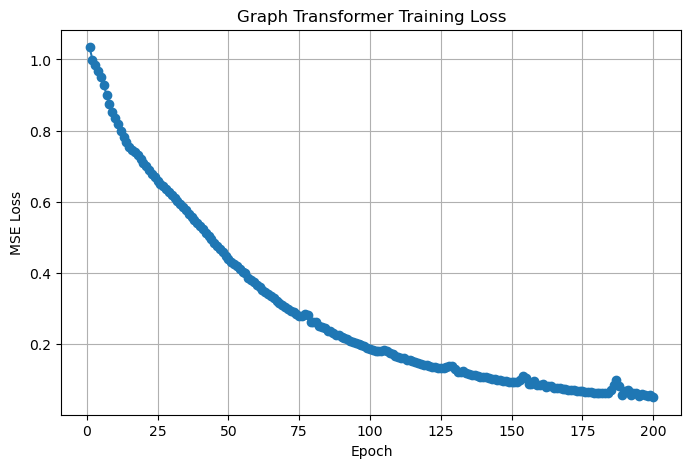

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_history, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Graph Transformer Training Loss")
plt.grid(True)
plt.show()

Save Graph Embeddings

In [14]:
model.eval()

with torch.no_grad():
    graph_embeddings = model(data.x, data.edge_index).cpu().numpy()

adata.obsm["X_graph"] = graph_embeddings

In [15]:
adata.write(os.path.join(BASE_PATH, "adata_with_graph_embeddings.h5ad"))

print("Graph embeddings saved.")

Graph embeddings saved.
